# **Problem Statement**

**Context**

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.


**Objective**


In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

1. Facilitate the process of visa approvals.
2. Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

**Data Description:**
The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

**case_id:** ID of each visa application

**continent:** Information of continent the employee

**education_of_employee:** Information of education of the employee

**has_job_experience:** Does the employee has any job experience? Y= Yes; N = No

**requires_job_training:** Does the employee require any job training? Y = Yes; N = No

**no_of_employees:** Number of employees in the employer's company

**yr_of_estab:** Year in which the employer's company was established

**region_of_employment:** Information of foreign worker's intended region of employment in the US.

**prevailing_wage:** Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.

**unit_of_wage:** Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.

**full_time_position:** Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position

**case_status:** Flag indicating if the Visa was certified or denied

# **Understanding the Data**

## Importing necessary libraries

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn import metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# loading the data from drive
from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/ML2-Coded-EasyVisa.csv')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Data Overview

In [ ]:
# viewing the first 5 rows of the data
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
# viewing the last 5 rows of the data
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [ ]:
# Checking the shape of the data
data.shape

(25480, 12)

* There are **25480 rows** and **12 Columns** are present in the given datasets.

### Checking the data types of the columns for the dataset

In [ ]:
# Checking the structure and data type of the given data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


* It can be observed that no columns have less entries (less than 25480 rows) which indicates that there are no missing values in the given dataset.

* There are attributes of different types (int, float, object) in the data.

* There are 3 numerical columns in the data and 9 categorical columns.

* Dependent variable is the case_status which is of categorical type.

### Statistical summary of the dataset

In [ ]:
# Numerical summary statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


•	The average number of employees is 5,667, but there is significant variation with a standard deviation of 22,878, suggesting some cases have many more employees than others.

•	The median number of employees is 2,109, indicating that half of the companies have fewer than this number of employees, showing a skew towards larger firms.

•	The range of employees is vast, with some companies reporting as few as -26 employees (which might indicate data issues or missing data corrections), while others have as many as 602,069.

•	The average establishment year is 1979, which means many companies have been in business for quite a while.

•	The oldest company in the dataset dates back to 1800, while the most recent was founded in 2016.

•	The average wage is around 74,456, but wages vary widely, as shown by the large standard deviation of 52,816.

•	The median wage is about 70,308, meaning half of the businesses offer wages below this value and the other half above.

•	The minimum wage reported is as low as 2.13, likely an outlier or a special case, and the highest wage reaches over 319,210.



In [ ]:
# Categorical summary statistics
data.describe(include='object').T

,count,unique,top,freq
case_id,25480,25480,EZYV01,1
continent,25480,6,Asia,16861
education_of_employee,25480,4,Bachelor's,10234
has_job_experience,25480,2,Y,14802
requires_job_training,25480,2,N,22525
region_of_employment,25480,5,Northeast,7195
unit_of_wage,25480,4,Year,22962
full_time_position,25480,2,Y,22773
case_status,25480,2,Certified,17018


In [ ]:
# Viewing the unique elements in categorical columns
for col in data.select_dtypes(include='object').columns:
  print(f'{col}: {data[col].unique()}')


case_id: ['EZYV01' 'EZYV02' 'EZYV03' ... 'EZYV25478' 'EZYV25479' 'EZYV25480']
continent: ['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']
education_of_employee: ['High School' "Master's" "Bachelor's" 'Doctorate']
has_job_experience: ['N' 'Y']
requires_job_training: ['N' 'Y']
region_of_employment: ['West' 'Northeast' 'South' 'Midwest' 'Island']
unit_of_wage: ['Hour' 'Year' 'Week' 'Month']
full_time_position: ['Y' 'N']
case_status: ['Denied' 'Certified']


In [ ]:
# Making a list of all categorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each categorical column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV01       1
EZYV16995    1
EZYV16993    1
EZYV16992    1
EZYV16991    1
            ..
EZYV8492     1
EZYV8491     1
EZYV8490     1
EZYV8489     1
EZYV25480    1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

•	There are 25,480 unique cases in this dataset, and each case has a unique identifier, with the most frequent identifier being “EZYV01,” though it only appears once, confirming the uniqueness of each case. This attribute can be drop as it will not add value to the analysis.

•	The dataset covers 6 continents, with the majority of cases (over 16,861) involving employees from Asia, indicating a strong representation of the Asian labor market in the data.

•	The education level of employees is distributed across 4 categories, with Bachelor’s degree being the most common qualification, held by 10,234 employees, reflecting the high demand for college-educated workers.

•	14,802 employees are marked as having prior job experience, which constitutes more than half of the dataset, showing that the majority of positions may require experienced workers.

•	The majority of cases (approximately 22,525) do not require job training, which could suggest that these positions either expect employees to be fully qualified or involve minimal training needs.

•	The data is divided into 5 regions, with the Northeast being the most common region of employment for 7,195 employees, likely due to a high concentration of businesses and industries in that area.

•	Yearly wages are the most commonly used wage unit, applied in 22,962 cases. This implies that long-term, stable employment is prevalent across the dataset.

•	Majority of cases (22,773) are for full-time positions, highlighting that most of the roles offered involve full-time commitments.

•	Of the two case statuses, “Certified” is the most frequent, with 17,018 cases approved, indicating a large number of applications have successfully met the necessary criteria.


In [ ]:
# checking the number of unique values
data.nunique()

,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


In [ ]:
for i in data.describe(include=["object"]).columns:
    print("Unique values in", i, "are :")
    print(data[i].value_counts())
    print("*" * 50)

Unique values in case_id are :
case_id
EZYV01       1
EZYV16995    1
EZYV16993    1
EZYV16992    1
EZYV16991    1
            ..
EZYV8492     1
EZYV8491     1
EZYV8490     1
EZYV8489     1
EZYV25480    1
Name: count, Length: 25480, dtype: int64
**************************************************
Unique values in continent are :
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
**************************************************
Unique values in education_of_employee are :
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
**************************************************
Unique values in has_job_experience are :
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
**************************************************
Unique values in requires_job_training are :
requires_job_

### Checking for duplicate values

In [ ]:
# let's check for duplicate values in the data
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
25475,False
25476,False
25477,False
25478,False


In [ ]:
# checking for the duplicate values
data.duplicated().sum()

0

### Checking for missing values

In [ ]:
# Checking for missing Values
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


•	There is no missing values.

•	There is no duplicate values.

•	There is no null values.


In [ ]:
# case_id consists of uniques ID for clients and hence will not add value to the modeling
data.drop(["case_id"], axis=1, inplace=True)

# **Exploratory Data Analysis**

#### The below functions need to be defined to carry out the Exploratory Data Analysis.

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
# function to plot stacked bar chart

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
### Function to plot distributions

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

## Univariate analysis

### Observation on no_of_employees:

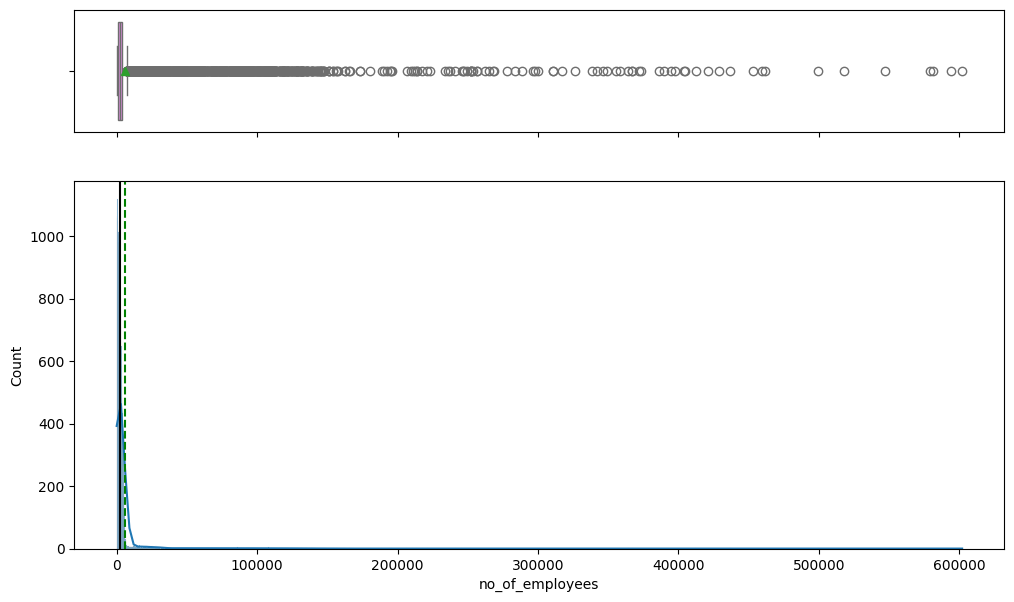

In [ ]:
histogram_boxplot(data, "no_of_employees", kde=True)

### Observation on yr_of_estab:

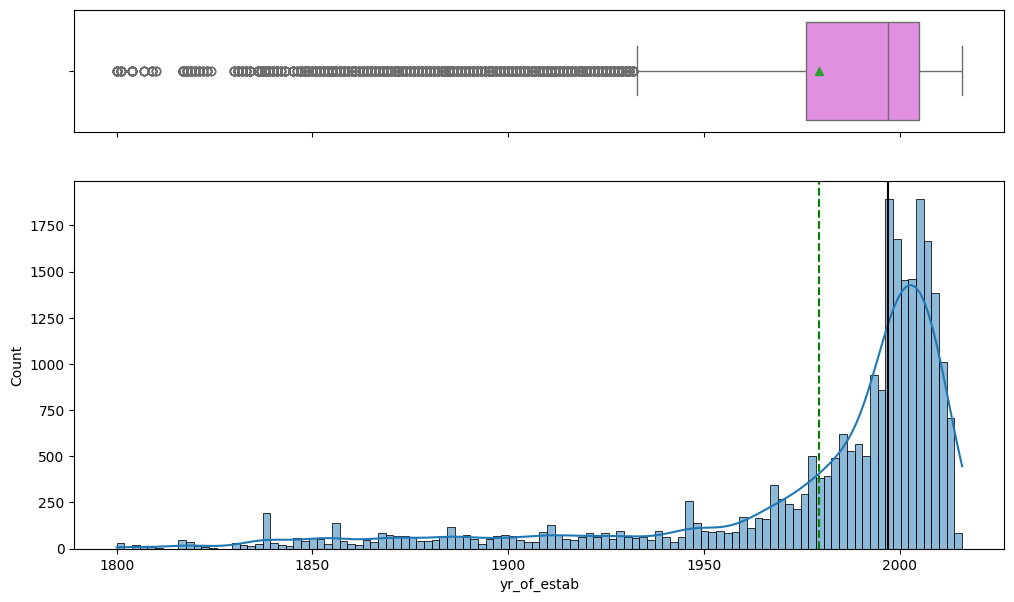

In [ ]:
histogram_boxplot(data, "yr_of_estab", kde=True)

### Observation on prevailing_wage:

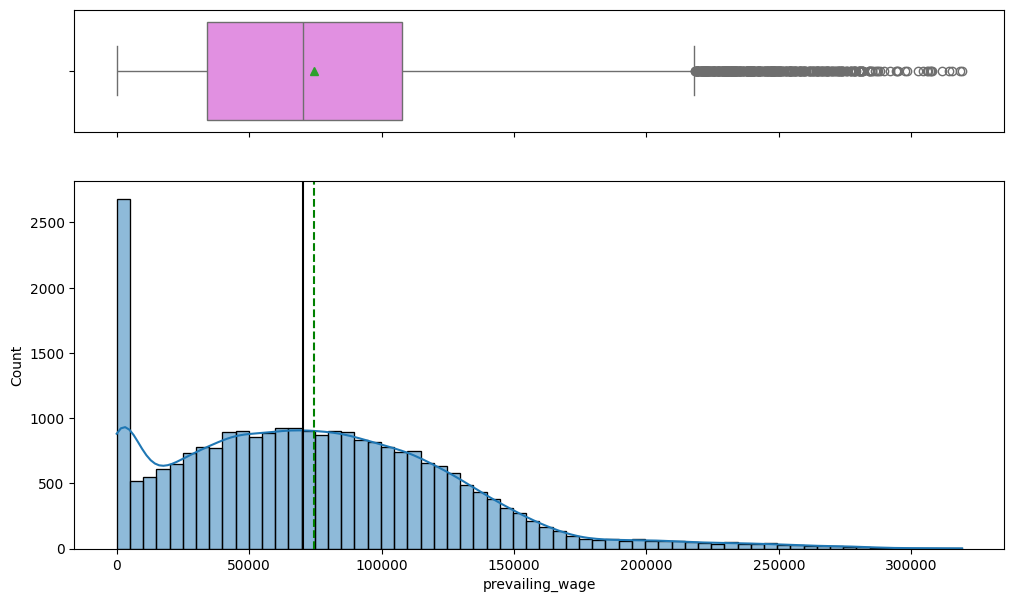

In [ ]:
histogram_boxplot(data, "prevailing_wage", kde=True)

### Observation on continent:

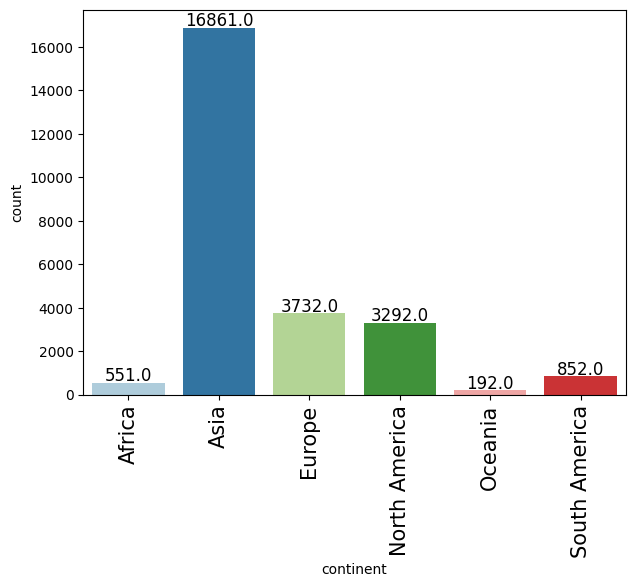

In [ ]:
labeled_barplot(data, "continent")

### Observation on education_of_employee:

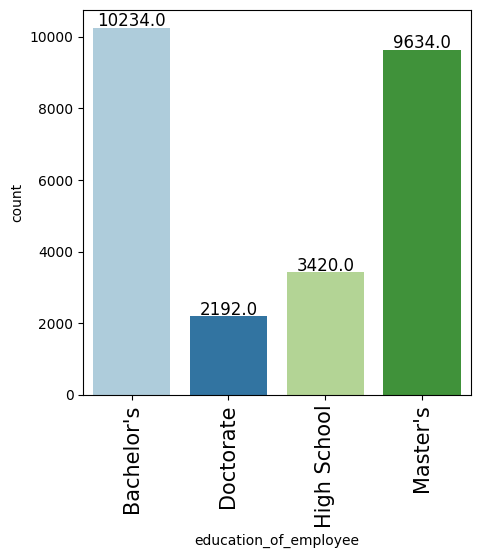

In [ ]:
labeled_barplot(data, "education_of_employee")

### Obsevarton on has_job_experience:

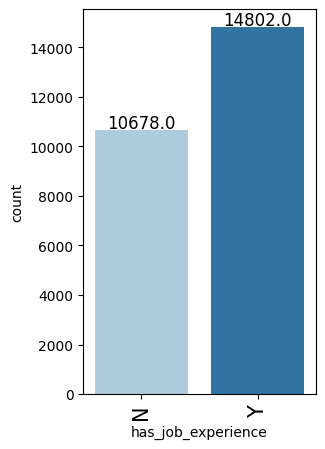

In [ ]:
labeled_barplot(data, "has_job_experience")

### Obsevarton on requires_job_training:

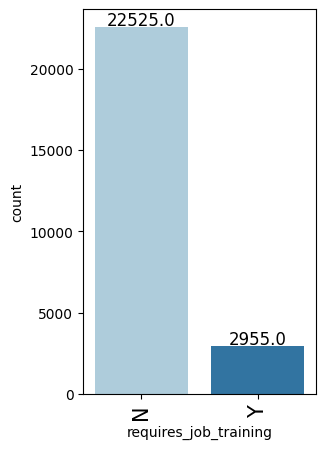

In [ ]:
labeled_barplot(data, "requires_job_training")

### Obsevarton on region_of_employment:

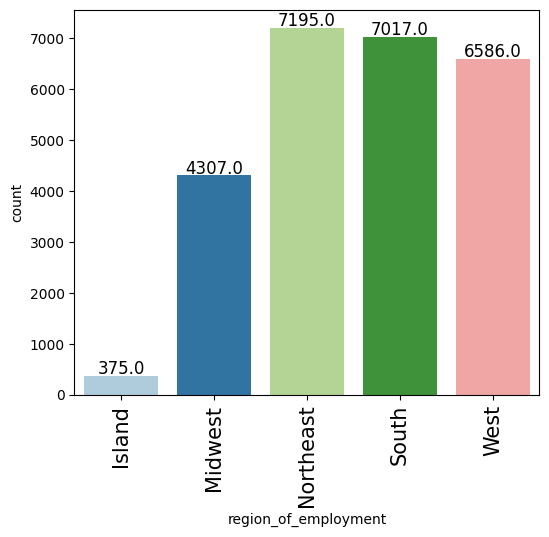

In [ ]:
labeled_barplot(data, "region_of_employment")

### Obsevarton on unit_of_wage:

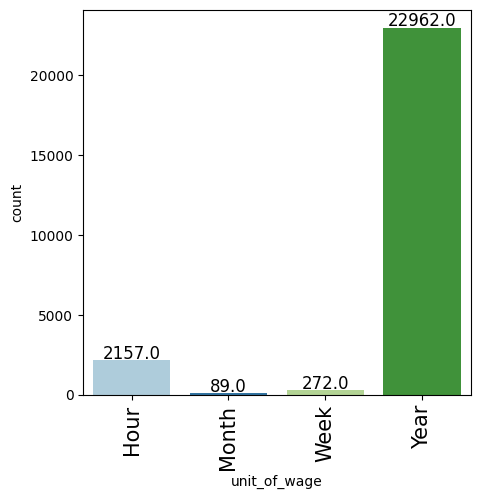

In [ ]:
labeled_barplot(data, "unit_of_wage")

### Obsevarton on full_time_position:

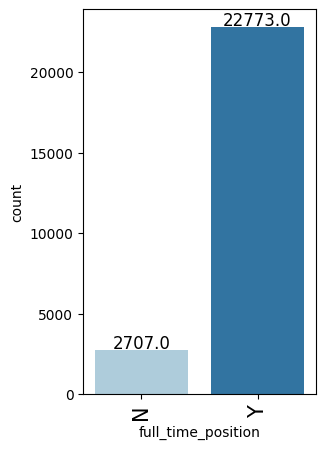

In [ ]:
labeled_barplot(data, "full_time_position")

### Obsevarton on case_status:

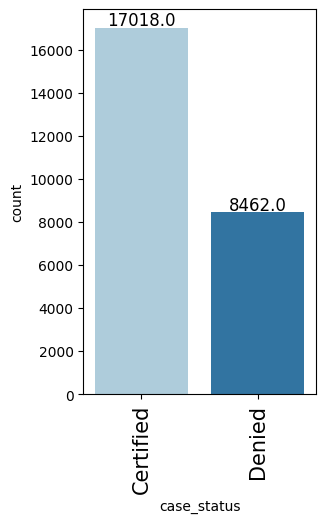

In [ ]:
labeled_barplot(data, "case_status")

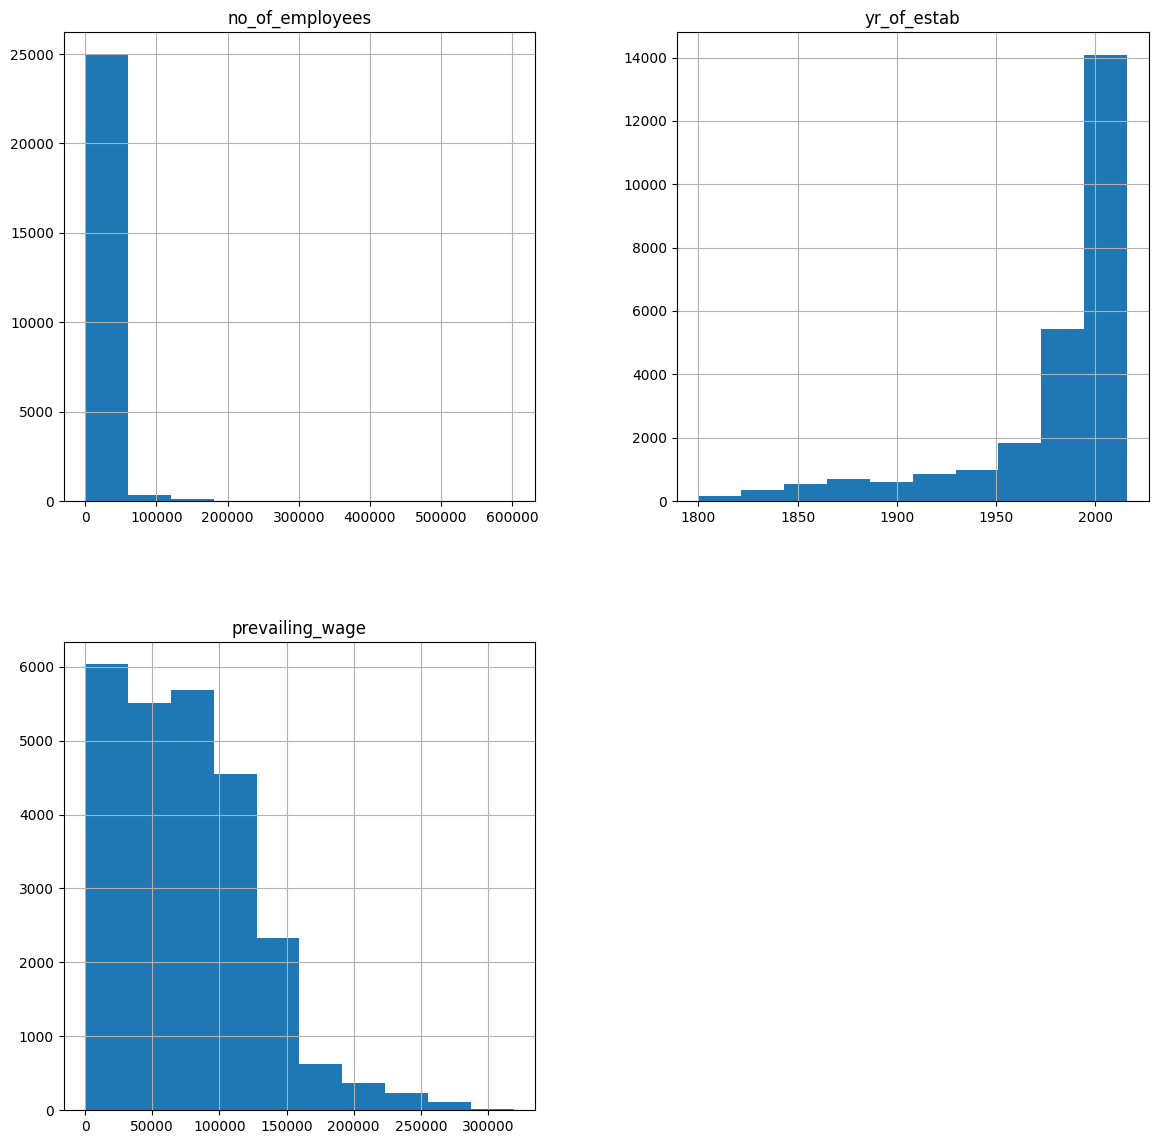

In [ ]:
# creating histograms
data.hist(figsize=(14, 14))
plt.show()

## Bivariate Amalysis

### Correlation Check

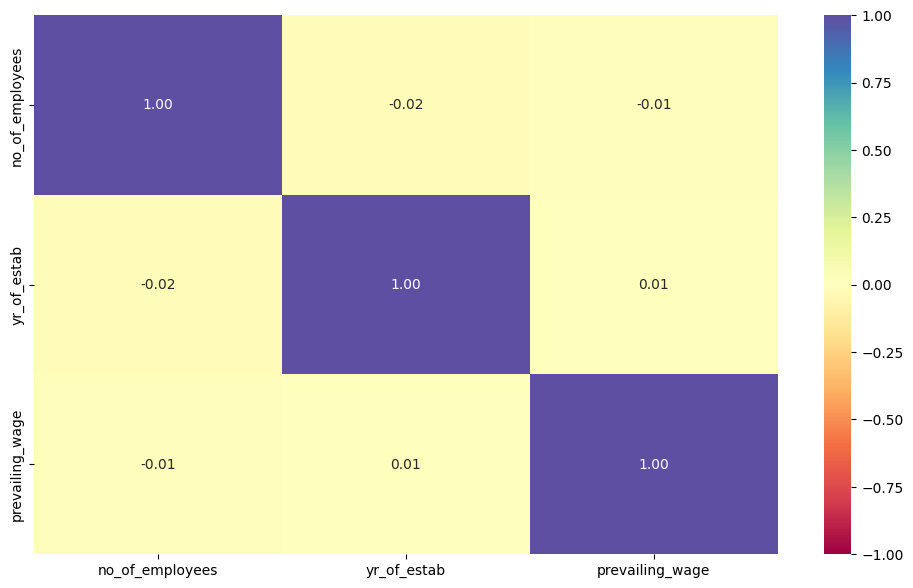

In [ ]:
# Plotting heatmap
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

### Observation on different features with respect to Case Status

### Observation on continent vs case_status

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


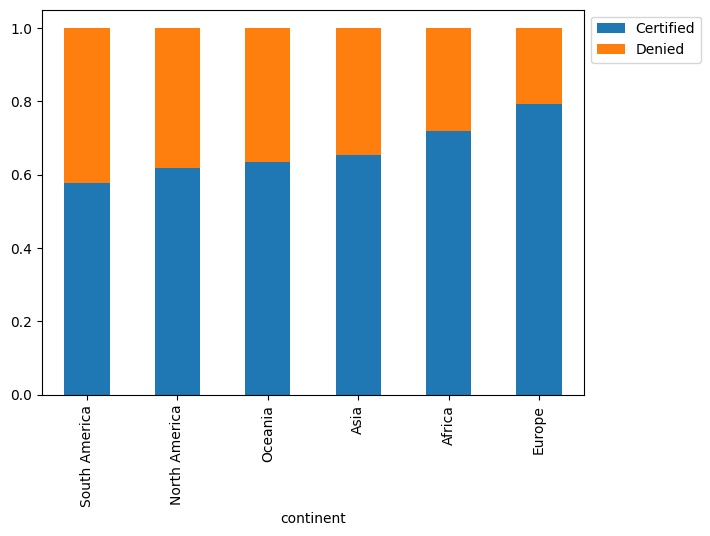

In [ ]:
stacked_barplot(data, "continent", "case_status")

### Observation on eductaion_of_employee vs case_status

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


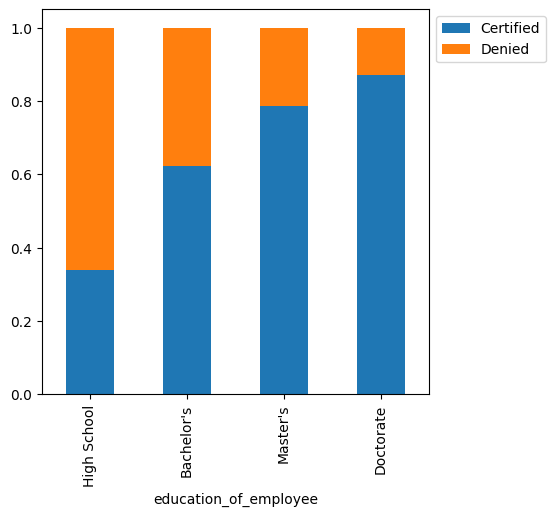

In [ ]:
stacked_barplot(data,"education_of_employee", "case_status")

### Observation on has_job_experience vs case_status

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


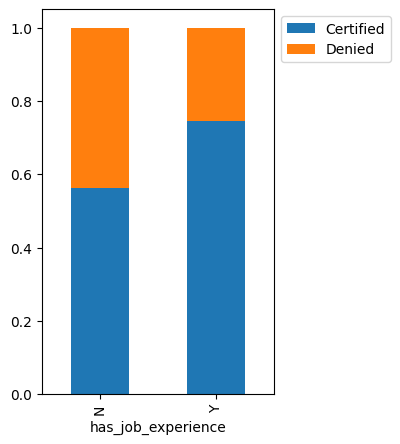

In [ ]:
stacked_barplot(data,"has_job_experience", "case_status")

### Observation on requires_job_training vs case_status

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


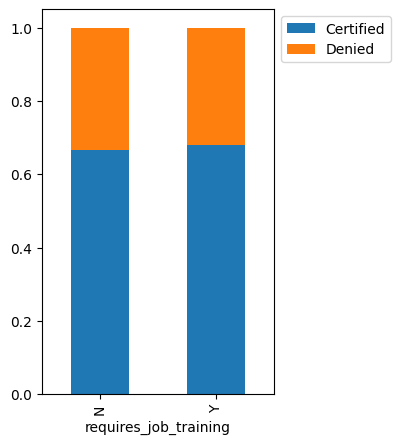

In [ ]:
stacked_barplot(data,"requires_job_training", "case_status")

### Observation on region_of_employment vs case_status

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


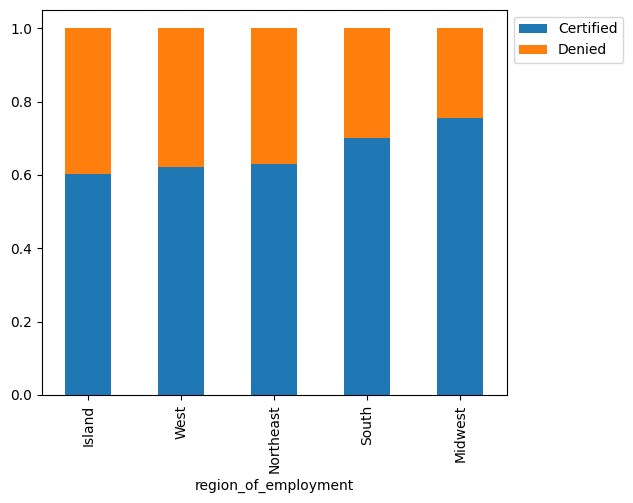

In [ ]:
stacked_barplot(data,"region_of_employment", "case_status")

### Observation on unit_of_wage vs case_status

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


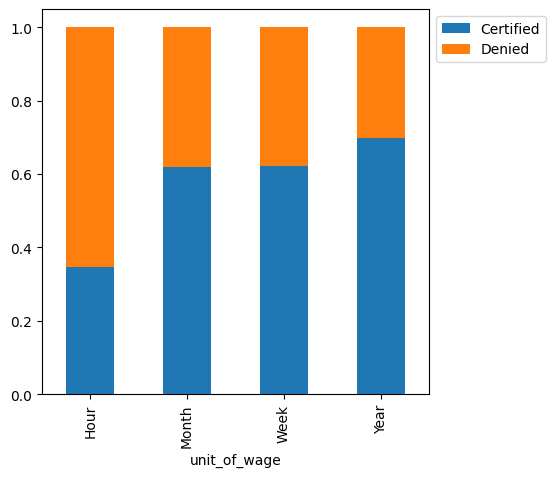

In [ ]:
stacked_barplot(data,"unit_of_wage", "case_status")

### Observation on full_time_position vs case_status



case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


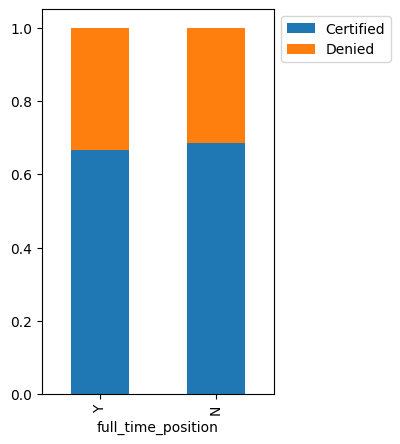

In [ ]:
stacked_barplot(data,"full_time_position", "case_status")

### Observation on no_of_employees vs case_status



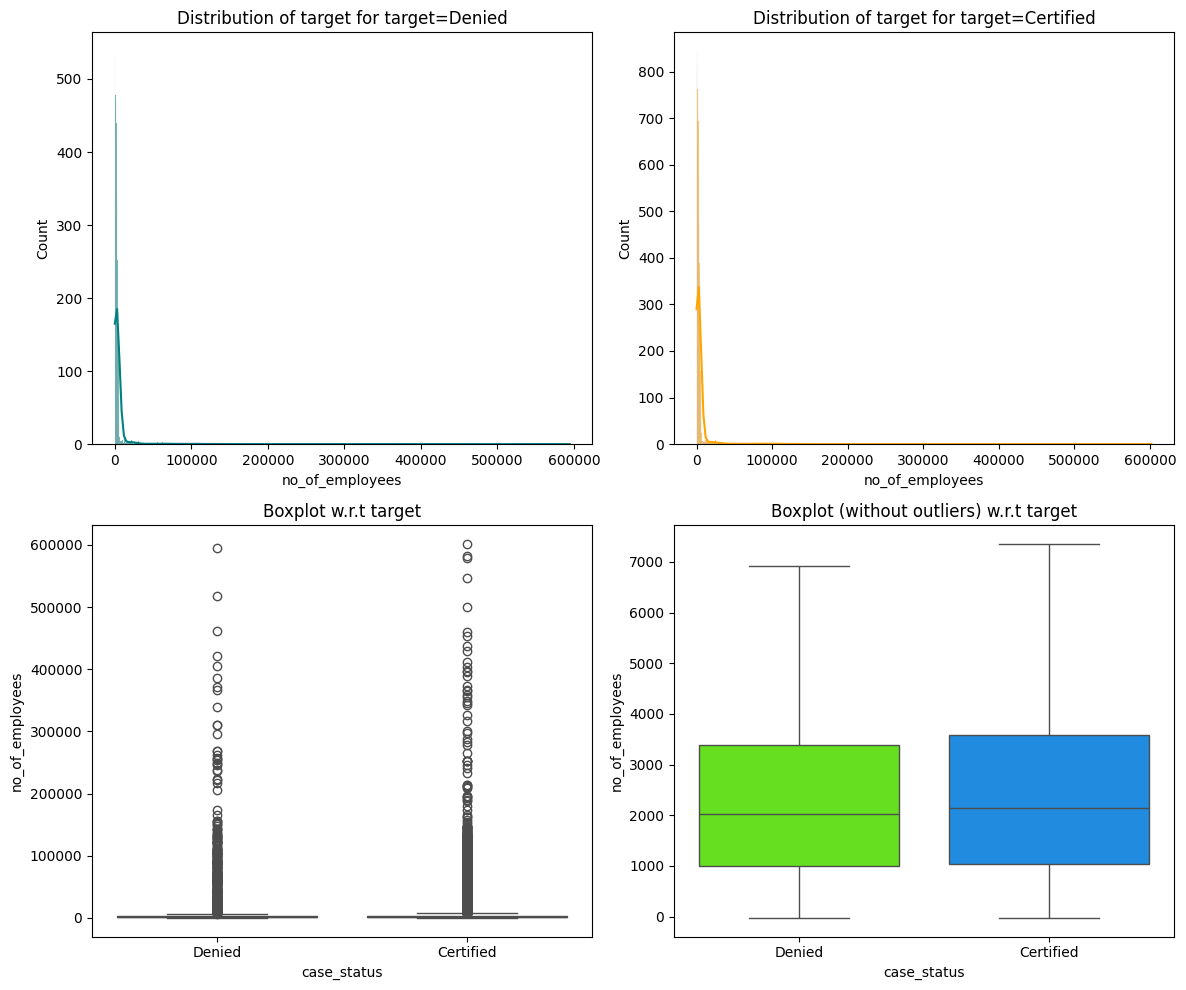

In [ ]:
distribution_plot_wrt_target(data, "no_of_employees", "case_status")

### Observation on yr_of_estab vs case_status



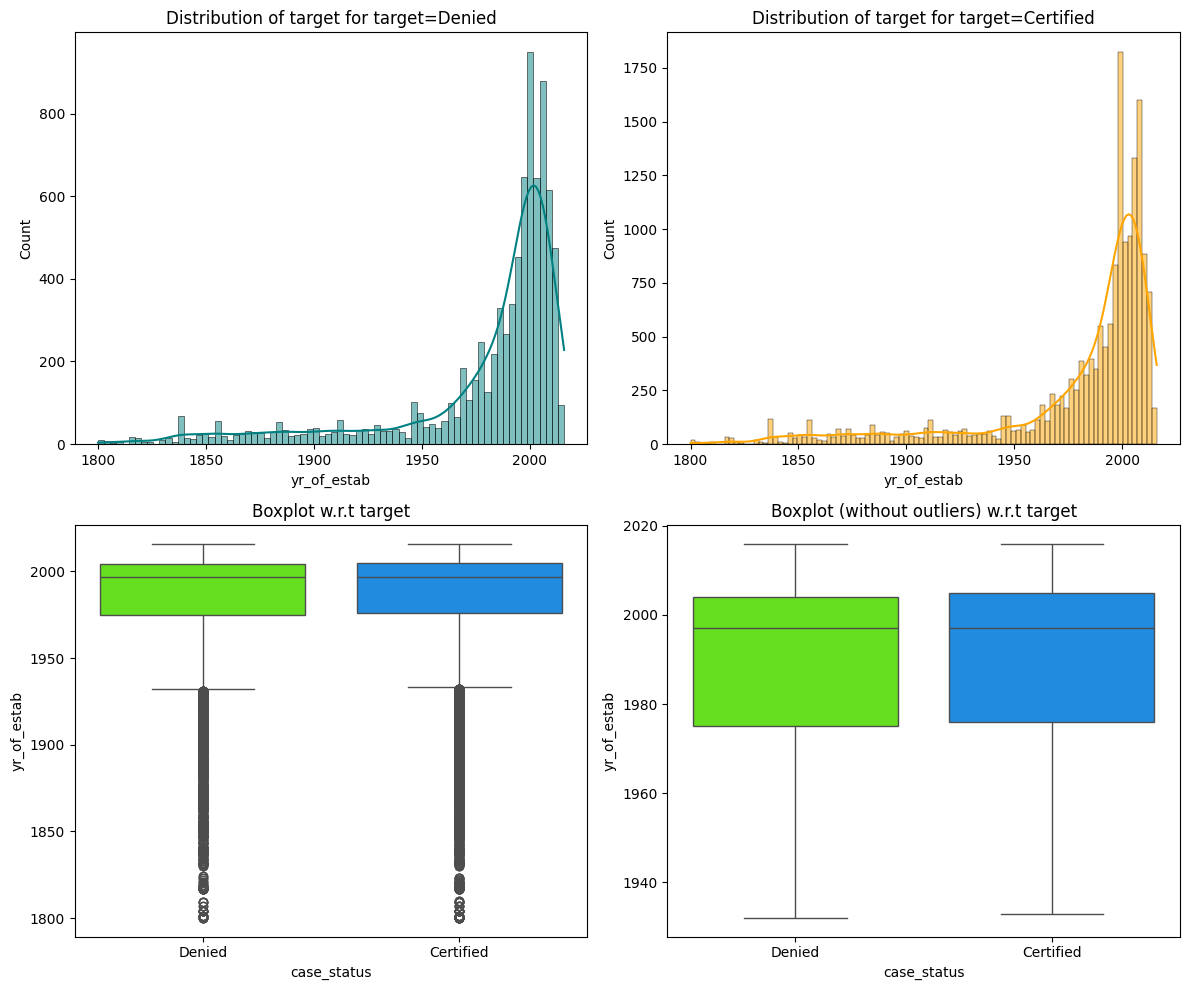

In [ ]:
distribution_plot_wrt_target(data, "yr_of_estab", "case_status")

### Observation on prevailing_wage vs case_status



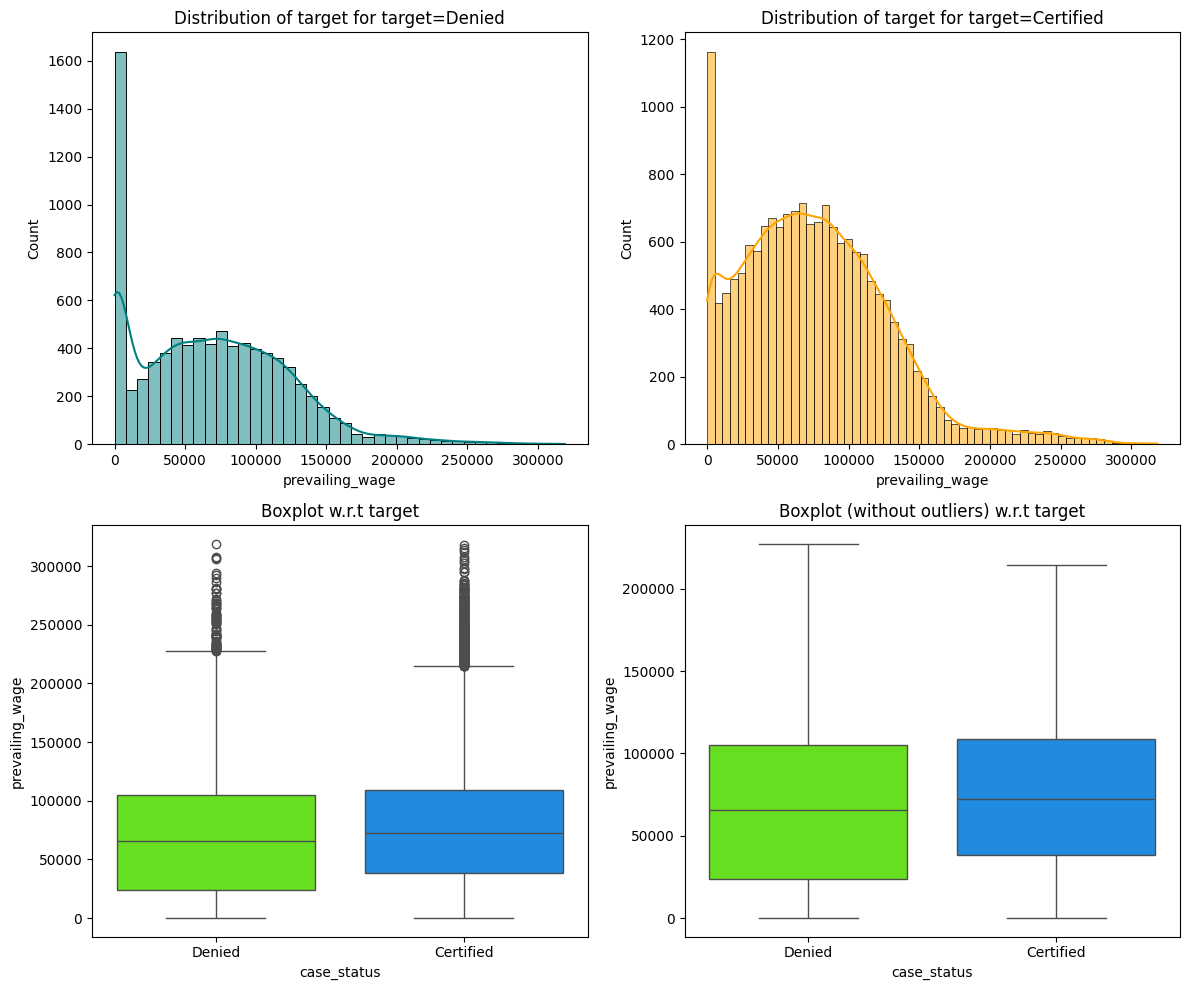

In [ ]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

# **Data Preprocessing**

### Outlier Detection

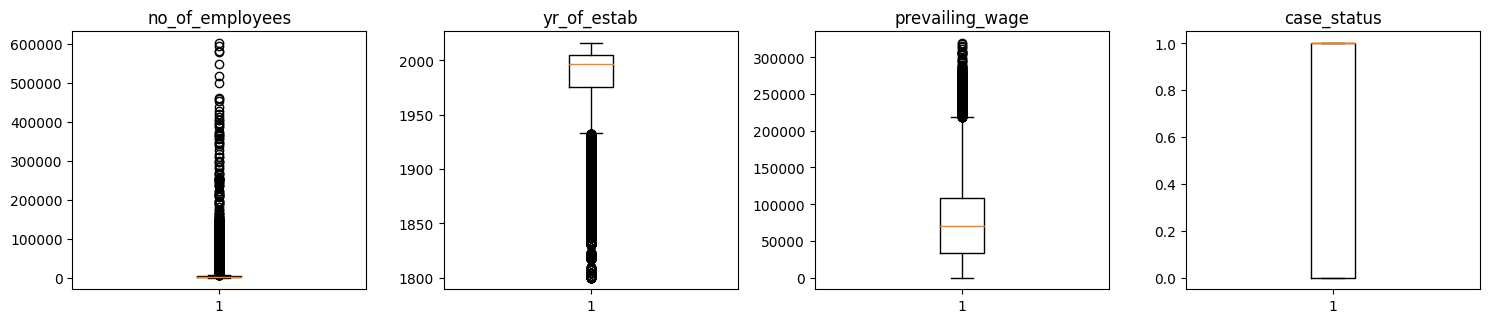

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
# dropping release_year as it is a temporal variable
#numeric_columns.remove("booking_status")

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Encoding Denied and Certified case status to 0 and 1 respectively, for analysis.**

In [ ]:
# Encoding Denied and Certified case status to 0 and 1 respectively, for analysis.
data["case_status"].replace("Denied", 0, inplace=True)
data["case_status"].replace("Certified", 1, inplace=True)

### Train-Test Split

In [ ]:
# creating the copy of the dataframe
data1 = data.copy()

In [ ]:
# creating an instace of the imputer to be used
imputer = SimpleImputer(strategy="most_frequent")

In [ ]:
# Dividing train data into X and y

X = data1.drop(["case_status"], axis=1)
y = data1["case_status"]

In [ ]:
# Splitting data into training and validation set:

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape, X_val.shape, X_test.shape)

(20384, 10) (6370, 10) (19110, 10)


### Encoding categorical variables

In [ ]:
# creating dummies
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
print(X_train.shape, X_val.shape, X_test.shape)

(20384, 21) (6370, 21) (19110, 21)


In [ ]:
# check the top 5 rows from the train dataset
X_train.head()

,no_of_employees,yr_of_estab,prevailing_wage,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y
3516,4069,1984,61313.770,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,True
13759,3022,1961,36588.110,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,True
6019,751,1971,210280.880,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True
779,1113,1968,46457.530,True,False,False,False,False,False,False,True,True,False,False,True,False,False,False,False,True,True
22792,796,1979,89542.270,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,True


# **Model Building**

### Model evaluation criterion

Model can make wrong predictions as:

* False Positive(FP): Predicting an applicant’s visa is marked as "certified" but it should have been "denied."

* False Negative(FN): Predicting an applicant’s visa is marked as "denied" but it should have been "certified."

To reduce the losses which might occur due false negative the recall need to be maximized, greater the recall score higher are the chances of minimizing the False Negatives.







**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Model Building - Original Data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("GradientBoosting", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9847216101072426
Random forest: 1.0
AdaBoost: 0.8859997061848097
GradientBoosting: 0.876156897311591
XGBoost: 0.9305127075069781

Validation Performance:

Bagging: 0.9410936399906126
Random forest: 0.9683172964092936
AdaBoost: 0.8946256747242431
GradientBoosting: 0.883126026754283
XGBoost: 0.9185637174372213


* The Random Forest and XGBoost models seem to perform best overall, achieving high recall score both in training and validation phases.
* AdaBoost and Gradient Boosting maintain more moderate and consistent performance, with less variance between training and validation.
* Bagging also performs well but shows a slightly more noticeable drop between training and validation.


### Model Building - Oversampled Data

In [ ]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 13614
Before Oversampling, counts of label 'No': 6770 

After Oversampling, counts of label 'Yes': 13614
After Oversampling, counts of label 'No': 13614 

After Oversampling, the shape of train_X: (27228, 21)
After Oversampling, the shape of train_y: (27228,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("GradientBoosting", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1))) ## Complete the code to append remaining 3 models in the list models


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))  ## Complete the code to build models on oversampled data
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9825914499779639
Random forest: 1.0
AdaBoost: 0.8580138093139416
GradientBoosting: 0.8552225650066109
XGBoost: 0.9068605846922286

Validation Performance:

Bagging: 0.9387467730579676
Random forest: 0.9619807556911523
AdaBoost: 0.8634123445200658
GradientBoosting: 0.8575451771884535
XGBoost: 0.9033090823750294


* Random Forest stands out as having the best performance in both training and validation datasets.
* Bagging and XGBoost also perform very well and generalize effectively, showing a good balance between training and validation performance.
* AdaBoost and Gradient Boosting exhibit slightly lower performances compared to the other models, with Gradient Boosting in particular showing a noticeable drop in validation accuracy.
* Random Forest, Bagging, and XGBoost seem to be the top models for this dataset, particularly in terms of generalization, while AdaBoost and Gradient Boosting may need further tuning to improve their performance.


### Model Building - Undersampled Data

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 13614
Before Under Sampling, counts of label 'No': 6770 

After Under Sampling, counts of label 'Yes': 6770
After Under Sampling, counts of label 'No': 6770 

After Under Sampling, the shape of train_X: (13540, 21)
After Under Sampling, the shape of train_y: (13540,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("GradientBoosting", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1))) ## Complete the code to append remaining 3 models in the list models


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))  ## Complete the code to build models on undersampled data
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9716395864106352
Random forest: 1.0
AdaBoost: 0.7276218611521418
GradientBoosting: 0.7515509601181684
XGBoost: 0.8462333825701625

Validation Performance:

Bagging: 0.7714151607603849
Random forest: 0.814362825627787
AdaBoost: 0.7204881483219902
GradientBoosting: 0.7470077446608777
XGBoost: 0.7580380192443088


* Random Forest once again outperforms the other models in both training and validation sets, showing the best generalization ability despite potential overfitting concerns from the perfect training score.
* Bagging also performs well, although its validation score shows a noticeable drop compared to training.
* XGBoost performs better in training compared to AdaBoost and Gradient Boosting, but its validation score is lower than expected, suggesting a gap in generalization.
* Both AdaBoost and Gradient Boosting exhibit weaker performance, with relatively close training and validation scores, indicating that they might not be able to fully capture the complexity of the dataset.


### Hyperparameter Tuning

#### **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.



#### Tuning AdaBoost using original data

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "estimator": [ # Changed base_estimator to estimator
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train) ## Complete the code to fit the model on original data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 50, 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.9165565705154582:


In [ ]:
# Creating new pipeline with best parameters
tuned_adb = AdaBoostClassifier( random_state=1,
    n_estimators= randomized_cv.best_params_['n_estimators'], learning_rate= randomized_cv.best_params_['learning_rate'], estimator= DecisionTreeClassifier(max_depth=randomized_cv.best_params_['estimator'].max_depth, random_state=1)
) ## Complete the code with the best parameters obtained from tuning

tuned_adb.fit(X_train, y_train) ## Complete the code to fit the model on original data

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.01, random_state=1)

In [ ]:
# Checking model's performance on Training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train, y_train) ## Complete the code to check the performance on training set
adb_train

,Accuracy,Recall,Precision,F1
0,0.737,0.914,0.748,0.823


In [ ]:
# Checking model's performance on validation set
adb_val =  model_performance_classification_sklearn(tuned_adb, X_val, y_val) ## Complete the code to check the performance on validation set
adb_val

,Accuracy,Recall,Precision,F1
0,0.739,0.916,0.749,0.824


#### Tuning Ada Boost using undersampled data

In [ ]:
# Creating new pipeline with best parameters
tuned_ada2 = AdaBoostClassifier( random_state=1,
    n_estimators= randomized_cv.best_params_['n_estimators'], learning_rate= randomized_cv.best_params_['learning_rate'], estimator= DecisionTreeClassifier(max_depth=randomized_cv.best_params_['estimator'].max_depth, random_state=1)
) ## Complete the code with the best parameters obtained from tuning

tuned_ada2.fit(X_train_un, y_train_un) ## Complete the code to fit the model on original data

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.01, random_state=1)

In [ ]:
adb2_train = model_performance_classification_sklearn(tuned_ada2, X_train_un, y_train_un) ## Complete the code to check the performance on training set
adb2_train

,Accuracy,Recall,Precision,F1
0,0.694,0.657,0.709,0.682


In [ ]:
# Checking model's performance on validation set
adb2_val = model_performance_classification_sklearn(tuned_ada2, X_val, y_val) ## Complete the code to check the performance on validation set
adb2_val

,Accuracy,Recall,Precision,F1
0,0.677,0.654,0.827,0.731


#### Tuning Gradient Boosting using undersampled data

In [ ]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un) ## Complete the code to fit the model on under sampled data


print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 75, 'max_features': 0.5, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.7549483013293944:
CPU times: user 4.38 s, sys: 495 ms, total: 4.87 s
Wall time: 3min 40s


In [ ]:
# Creating new pipeline with best parameters
tuned_gbm1 = GradientBoostingClassifier(
    max_features=randomized_cv.best_params_['max_features'],
    init=randomized_cv.best_params_['init'],
    random_state=1,
    learning_rate=randomized_cv.best_params_['learning_rate'],
    n_estimators=randomized_cv.best_params_['n_estimators'],
    subsample=randomized_cv.best_params_['subsample'],
)## Complete the code with the best parameters obtained from tuning

tuned_gbm1.fit(X_train_un, y_train_un)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.5,
                           n_estimators=75, random_state=1, subsample=0.7)

In [ ]:
gbm1_train = model_performance_classification_sklearn(tuned_gbm1, X_train_un, y_train_un) ## Complete the code to check the performance on undersampled train set
gbm1_train

,Accuracy,Recall,Precision,F1
0,0.715,0.767,0.695,0.729


In [ ]:
gbm1_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val) ## Complete the code to check the performance on validation set
gbm1_val

,Accuracy,Recall,Precision,F1
0,0.728,0.764,0.818,0.790


#### Tuning Gradient Boosting using original data

In [ ]:
%%time

#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train) ## Complete the code to fit the model on original data


print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'n_estimators': 100, 'max_features': 1, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.990377449775405:
CPU times: user 5.24 s, sys: 605 ms, total: 5.84 s
Wall time: 4min 50s


In [ ]:
# Creating new pipeline with best parameters
tuned_gbm2 = GradientBoostingClassifier(
    max_features=randomized_cv.best_params_['max_features'],
    init=randomized_cv.best_params_['init'],
    random_state=1,
    learning_rate=randomized_cv.best_params_['learning_rate'],
    n_estimators=randomized_cv.best_params_['n_estimators'],
    subsample=randomized_cv.best_params_['subsample'],
)## Complete the code with the best parameters obtained from tuning

tuned_gbm2.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=1, random_state=1,
                           subsample=0.9)

#### Tuning Gradient Boosting using over sampled data

In [ ]:
gbm2_train = model_performance_classification_sklearn(tuned_gbm2, X_train, y_train) ## Complete the code to check the performance on oversampled train set
gbm2_train

,Accuracy,Recall,Precision,F1
0,0.678,0.995,0.676,0.805


In [ ]:
gbm2_val = model_performance_classification_sklearn(tuned_gbm2, X_val, y_val) ## Complete the code to check the performance on validation set
gbm2_val

,Accuracy,Recall,Precision,F1
0,0.679,0.995,0.677,0.806


#### Tuning XGBoost Model with Original data

**Note**: This section is optional. You can choose not to build XGBoost if you are facing issues with installation or if it is taking more time to execute.



In [ ]:
%%time

# defining model
Model = XGBClassifier(random_state=1,eval_metric='logloss')

#Parameter grid to pass in RandomSearchCV
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
           }
from sklearn import metrics

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train) ## Complete the code to fit the model on original data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'scale_pos_weight': 5, 'n_estimators': 50, 'learning_rate': 0.01, 'gamma': 3} with CV score=1.0:
CPU times: user 4.01 s, sys: 273 ms, total: 4.28 s
Wall time: 1min 14s


In [ ]:
tuned_xgb = XGBClassifier(
    random_state=1,
    eval_metric="logloss",
    subsample=randomized_cv.best_params_['subsample'],
    scale_pos_weight=randomized_cv.best_params_['scale_pos_weight'],
    n_estimators=randomized_cv.best_params_['n_estimators'],
    learning_rate=randomized_cv.best_params_['learning_rate'],
    gamma=1,
)## Complete the code with the best parameters obtained from tuning

tuned_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [ ]:
xgb_train = model_performance_classification_sklearn(tuned_xgb, X_train, y_train) ## Complete the code to check the performance on original train set
xgb_train

,Accuracy,Recall,Precision,F1
0,0.668,1.000,0.668,0.801


In [ ]:
xgb_val = model_performance_classification_sklearn(tuned_xgb, X_val, y_val) ## Complete the code to check the performance on validation set
xgb_val

,Accuracy,Recall,Precision,F1
0,0.669,1.000,0.669,0.802


# **Model Comparison and Final Model Selection**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm1_train.T,
        gbm2_train.T,
        adb2_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Original data",
    "AdaBoost trained with Undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Undersampled data,Gradient boosting trained with Original data,AdaBoost trained with Undersampled data
Accuracy,0.715,0.678,0.694
Recall,0.767,0.995,0.657
Precision,0.695,0.676,0.709
F1,0.729,0.805,0.682


In [ ]:
# validation performance comparison
models_val_comp_df = pd.concat(
    [
        gbm1_val.T,
        gbm2_val.T,
        adb2_val.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Original data",
    "AdaBoost trained with Undersampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient boosting trained with Undersampled data,Gradient boosting trained with Original data,AdaBoost trained with Undersampled data
Accuracy,0.728,0.679,0.677
Recall,0.764,0.995,0.654
Precision,0.818,0.677,0.827
F1,0.790,0.806,0.731


**Now we have our final model, so let's find out how our final model is performing on unseen test data.**

In [ ]:
# Let's check the performance on test set
test_performance = model_performance_classification_sklearn(tuned_gbm1, X_test, y_test)
test_performance

,Accuracy,Recall,Precision,F1
0,0.724,0.758,0.816,0.786


•	If recall (identifying as many true positives as possible) is the priority, Gradient Boosting (Original data) may be the preferred choice.

•	If precision (reducing false positives) is more critical, AdaBoost (Undersampled data) would be the better option.

•	The Gradient Boosting (Undersampled data) seems to be the best model overall offers a balanced performance with strong generalization, making it an all-around solid choice for many cases.


### Feature Importances

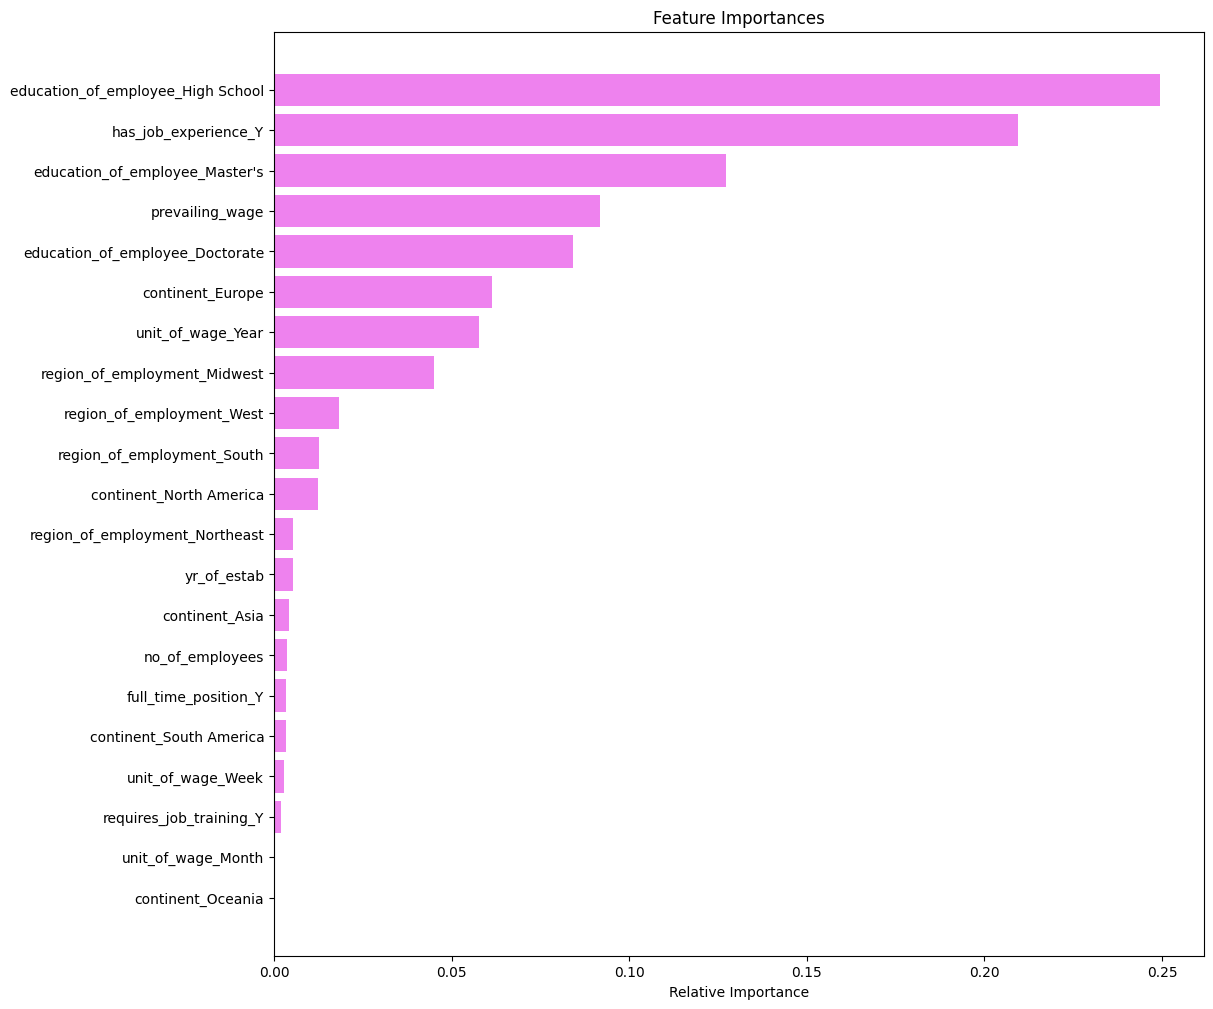

In [ ]:
feature_names = X_train.columns
importances =  tuned_gbm1.feature_importances_ ##Checking the feature importance of the best model
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# **Business Insights and Conclusions**


•	Education, particularly at the high school, Master’s, and Doctorate levels, plays a critical role in visa approval decisions. Companies should prioritize applicants with higher educational qualifications as they have a higher likelihood of visa certification.

•	EasyVisa’s model suggests that educational background is one of the top determinants of visa outcomes. Hence, companies can streamline their recruitment by focusing on highly educated candidates when applying for foreign labor certifications.

•	Job experience is the second most influential factor in the visa certification process. Candidates with previous job experience are more likely to have their visa applications approved. Employers should seek candidates who have demonstrable job experience, as they are more likely to meet the approval criteria. Additionally, the OFLC should encourage companies to prioritize skilled workers with experience to improve the chances of visa certification

•	Region of employment (such as Midwest and Europe) has a moderate influence on visa approvals. Different regions may have varying demand or labor shortages that influence decisions. Employers in regions with higher labor demand (such as the Midwest) may benefit from better odds of visa certification. Companies should be aware of regional trends when planning recruitment from abroad and collaborate with OFLC to understand how geographic preferences impact approval rates.

•	Full-time positions have a slight impact on the approval process, though it's not a dominant factor. While full-time positions are generally more favorable, companies should still prioritize experience, education, and prevailing wages over full-time status when making visa applications.

•	Implement Gradient Boosting (Undersampled data) model to predict the likelihood of visa certification based on applicant attributes. Such a model can assist OFLC in automatically shortlisting high-potential candidates, reducing the manual review workload.


***

# Conclusion:

The analysis identifies key factors influencing visa certification, providing actionable insights that can guide the development of more effective visa processing strategies. By focusing on education, experience, training requirements, and wage adjustments, EasyVisa can help streamline the visa approval process, ensuring that the U.S. attracts the right talent to meet its workforce needs. Future steps include developing predictive models and optimizing application review workflows to further enhance the visa certification process.

These insights will help companies stay competitive by attracting the best talent from abroad while navigating the growing complexity of the visa approval process efficiently.
